In [1]:
# ===============================
# ===============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

import shap

In [2]:
# ===============================

train_path = r"D:\paper 6\training_value.csv"
test_path = r"D:\paper 6\test_value.csv"
output_dir = r"D:\paper 6\SHAP_PDP_value"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

train_dataset = pd.read_csv(train_path)
test_dataset = pd.read_csv(test_path)

train_dataset.head()

,Bulk density,Initial C/N ratio,Initial moisture content,Initial pH,Composting duration,Reactor volume,Score
0,0.33,24.40,61.37,5.10,8,180.0,75.21
1,0.15,21.47,60.95,5.65,91,45000.0,83.20
2,0.13,30.83,80.12,5.41,150,10000.0,80.43
3,0.33,25.00,57.50,6.70,90,150.0,33.74
4,0.50,35.72,58.42,6.40,27,60.0,71.30


In [3]:
# ===============================
# ===============================

feature_names = [
    'Bulk density',
    'Initial C/N ratio',
    'Initial moisture content',
    'Initial pH',
    'Composting duration',
    'Reactor volume'
]

# ===============================

X_train = train_dataset[feature_names]
Y_train = train_dataset['Score']

X_test = test_dataset[feature_names]
Y_test = test_dataset['Score']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (264, 6)
X_test shape: (114, 6)


In [4]:
# 4. XGBoost
# ===============================

from xgboost import XGBRegressor

X = pd.concat([X_train, X_test], axis=0, ignore_index=True)

xgb = XGBRegressor(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.07,
    subsample=0.90,
    colsample_bytree=1.00,
    min_child_weight=3,
    gamma=0,
    reg_alpha=0,
    reg_lambda=3,
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist'
)

model = xgb.fit(X_train, Y_train)

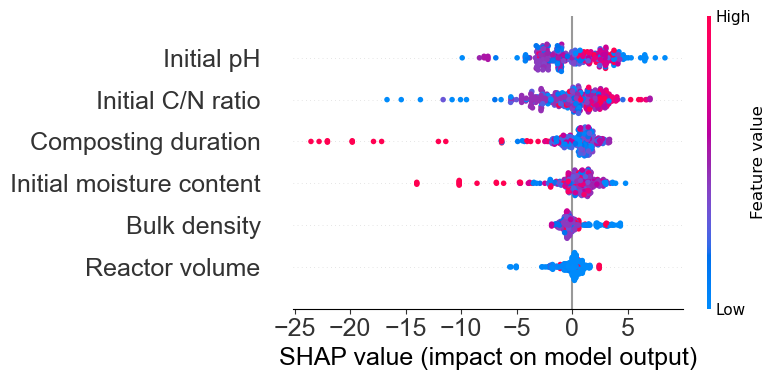

In [5]:
# ===============================
# 5. SHAP
# ===============================
X = pd.concat([X_train, X_test], axis=0, ignore_index=True)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)


# SHAP summary plot
shap.summary_plot(
    shap_values,
    X,
    max_display=30,
    show=False
)

plt.xlabel('SHAP value (impact on model output)',
           fontsize=18,
           family='Arial')
plt.xticks(fontsize=18, family='Arial')
plt.yticks(fontsize=18, family='Arial')
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, 'SHAP_summary_value.svg'),
    dpi=2000,
    bbox_inches='tight'
)

plt.show()

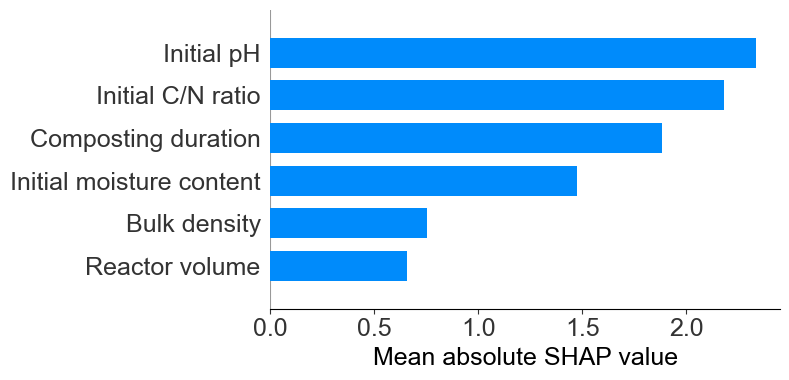

In [6]:
# ===============================
# 6. SHAP bar plot
# ===============================

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    max_display=30,
    show=False
)

plt.xlabel('Mean absolute SHAP value',
           fontsize=18,
           family='Arial')
plt.xticks(fontsize=18, family='Arial')
plt.yticks(fontsize=18, family='Arial')
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, 'SHAP_bar_value.svg'),
    dpi=2000,
    bbox_inches='tight'
)

plt.show()

In [7]:
# ===============================
# 7. Output SHAP numerical results
# ===============================

shap_df = pd.DataFrame(
    data=shap_values,
    columns=feature_names
)

shap_df.to_csv(
    os.path.join(output_dir, 'shap_values_value.csv'),
    index=False,
    encoding='utf-8-sig'
)

abs_shap_df = abs(shap_df)

abs_shap_df.to_csv(
    os.path.join(output_dir, 'abs_shap_values_value.csv'),
    index=False,
    encoding='utf-8-sig'
)

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_abs_SHAP': abs_shap_df.mean(axis=0)
}).sort_values(by='Mean_abs_SHAP', ascending=False)

shap_importance.to_csv(
    os.path.join(output_dir, 'SHAP_importance_ranking_value.csv'),
    index=False,
    encoding='utf-8-sig'
)

shap_importance

,Feature,Mean_abs_SHAP
Initial pH,Initial pH,2.334810
Initial C/N ratio,Initial C/N ratio,2.182304
Composting duration,Composting duration,1.885282
Initial moisture content,Initial moisture content,1.476312
Bulk density,Bulk density,0.752347
Reactor volume,Reactor volume,0.659198


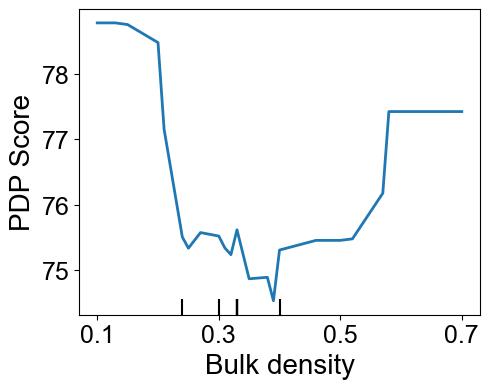

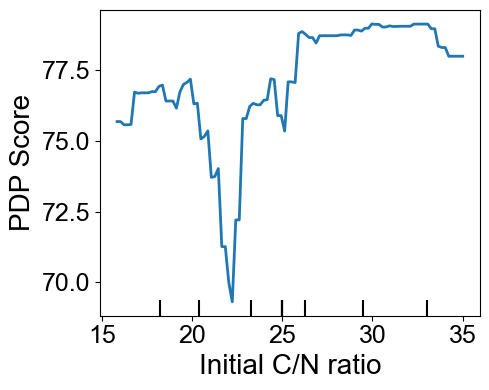

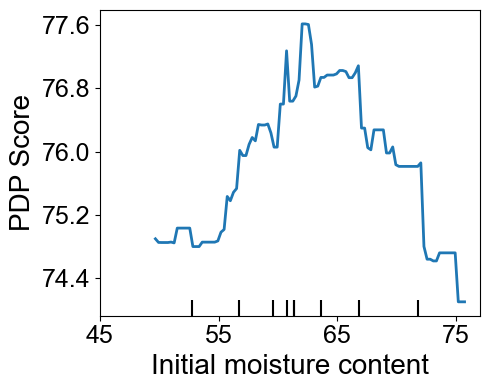

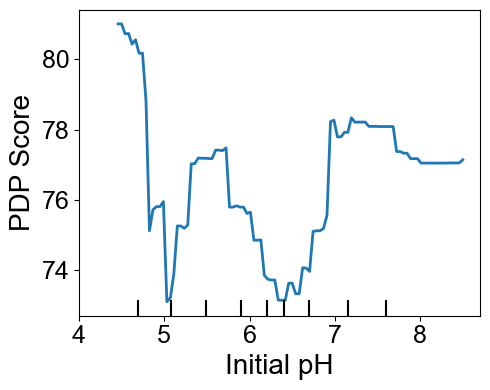

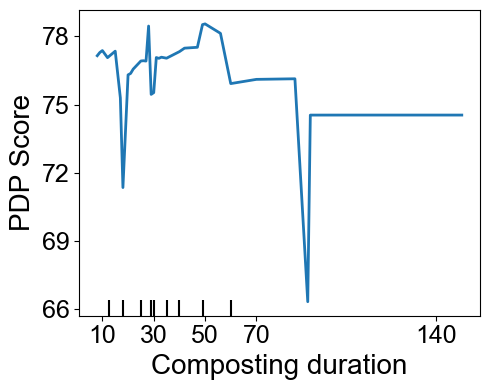

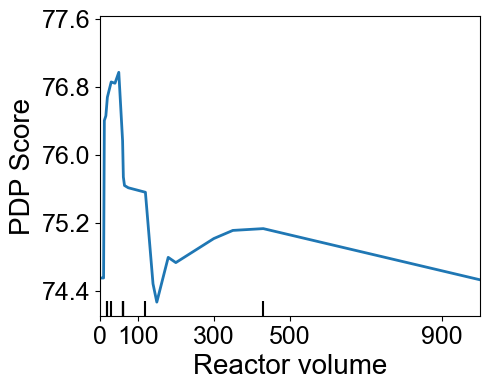

In [13]:
# ===============================
# 9. PDP analysis: Single-factor PDP
# ===============================

pdp_dir = os.path.join(output_dir, 'PDP_single')
if not os.path.exists(pdp_dir):
    os.makedirs(pdp_dir)

for feature in feature_names:
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    disp = PartialDependenceDisplay.from_estimator(
        model,
        X,
        features=[feature],
        grid_resolution=100,
        ax=ax
    )
    

    ax = disp.axes_[0, 0]

 
    for line in ax.lines:
        line.set_linewidth(2.0)

    ax.set_xlabel(feature, fontsize=20, fontname='Arial')
    ax.set_ylabel('PDP Score', fontsize=20, fontname='Arial')

    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
    if feature == 'Bulk density':
        ax.set_xticks([0.1, 0.3, 0.5, 0.7])
    if feature == 'Initial C/N ratio':
        ax.set_xticks([15, 20, 25, 30, 35])
    if feature == 'Initial moisture content':
        ax.set_xticks([45, 55, 65, 75])
    if feature == 'Initial pH':
        ax.set_xticks([4, 5, 6, 7, 8])
    if feature == 'Composting duration':
        ax.set_xticks([10, 30, 50, 70, 140])
    if feature == 'Reactor volume':
        ax.set_xlim(0, 1000)
        ax.set_xticks([0, 100, 300, 500, 900])


    for label in ax.get_xticklabels():
        label.set_fontsize(18)
        label.set_fontname('Arial')
        
    for label in ax.get_yticklabels():
        label.set_fontsize(18)
        label.set_fontname('Arial')
    
    ax.set_title('', fontsize=20)
    
    plt.tight_layout()
    
    filename = 'PDP_' + feature.replace('/', '_').replace(' ', '_') + '.svg'
    
    plt.savefig(
        os.path.join(pdp_dir, filename),
        dpi=2000,
        bbox_inches='tight'
    )
    
    plt.show()

SHAP ranking:
1 Initial pH
2 Initial C/N ratio
3 Composting duration
4 Initial moisture content
5 Bulk density
6 Reactor volume

Top 4 features used for two-feature PDP:
Initial pH
Initial C/N ratio
Composting duration
Initial moisture content

Two-feature PDP: Initial pH + Initial C/N ratio


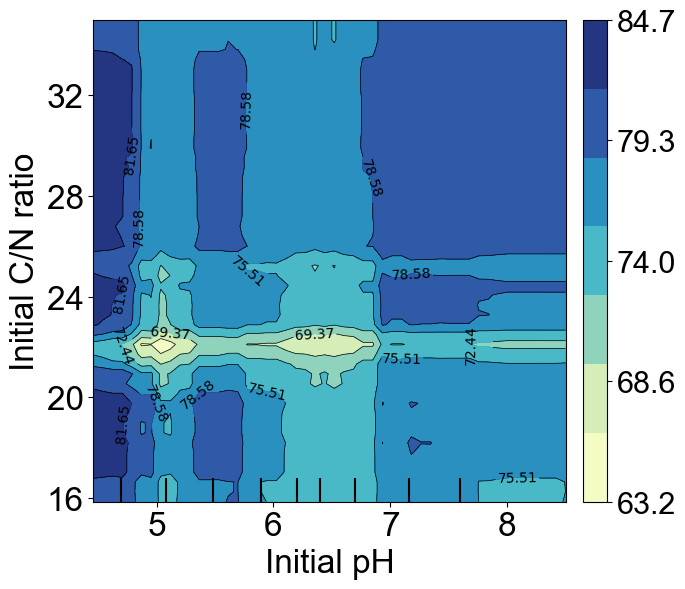


Two-feature PDP: Initial pH + Composting duration


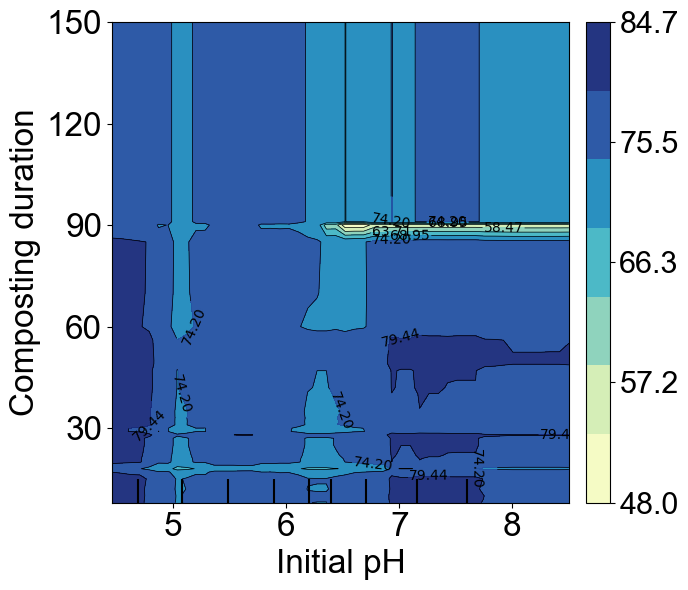


Two-feature PDP: Initial pH + Initial moisture content


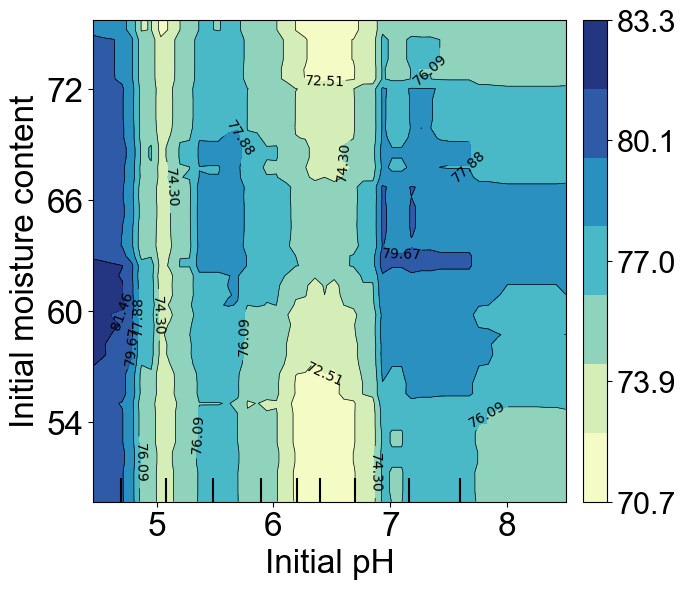


Two-feature PDP: Initial C/N ratio + Composting duration


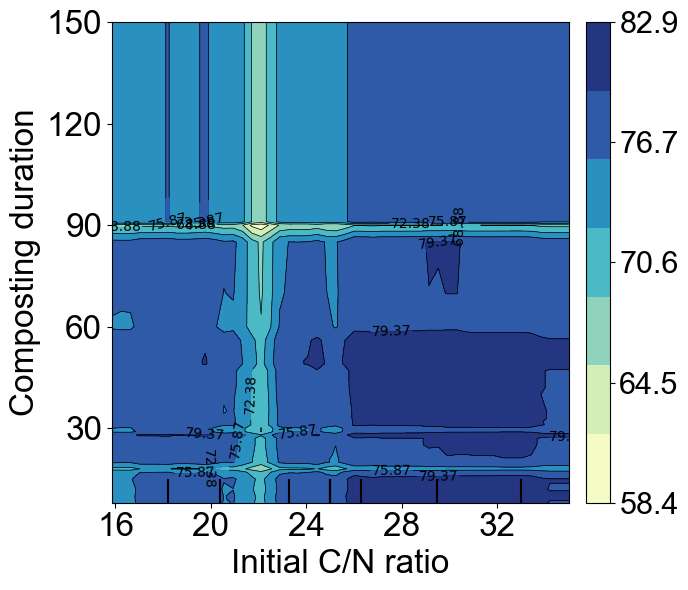


Two-feature PDP: Initial C/N ratio + Initial moisture content


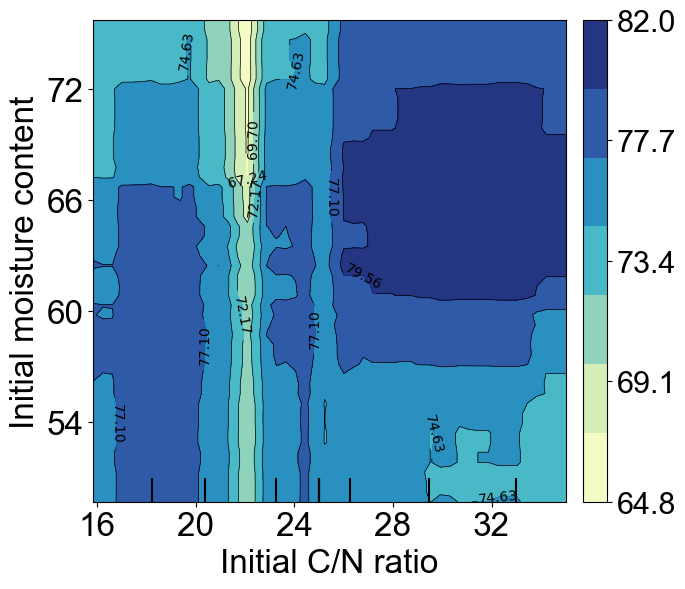


Two-feature PDP: Composting duration + Initial moisture content


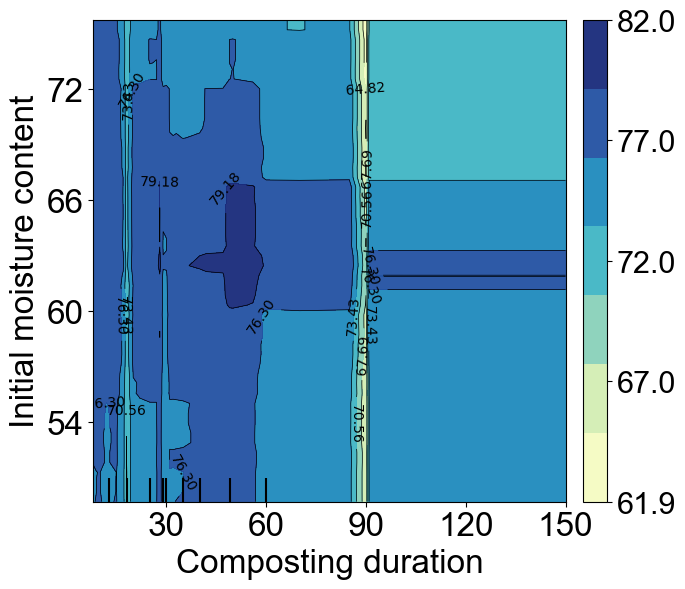

In [22]:
# ===============================
# 10. PDP
# ===============================

from matplotlib.ticker import MaxNLocator, FormatStrFormatter

pdp2_dir = os.path.join(output_dir, 'PDP_two_features')
if not os.path.exists(pdp2_dir):
    os.makedirs(pdp2_dir)


# ===============================
mean_abs_shap = np.abs(shap_values).mean(axis=0)

ranked_features = [
    feature_names[i]
    for i in np.argsort(mean_abs_shap)[::-1]
]

print("SHAP ranking:")
for i, feature in enumerate(ranked_features, 1):
    print(i, feature)


# ===============================
top_features = ranked_features[:4]

print("\nTop 4 features used for two-feature PDP:")
for feature in top_features:
    print(feature)

cmap_name = 'YlGnBu'

# ===============================
for i in range(len(top_features)):
    for j in range(i + 1, len(top_features)):

        f1 = top_features[i]
        f2 = top_features[j]

        print("\nTwo-feature PDP:", f1, "+", f2)

        fig, ax = plt.subplots(figsize=(7, 6))

        disp = PartialDependenceDisplay.from_estimator(
            model,
            X,
            features=[(f1, f2)],
            grid_resolution=50,
            ax=ax,
            contour_kw={
                'cmap': cmap_name,
                'alpha': 0.95
            }
        )

 
        ax = disp.axes_[0, 0]


        # ===============================
        ax.set_xlabel(f1, fontsize=24, fontname='Arial')
        ax.set_ylabel(f2, fontsize=24, fontname='Arial')
        ax.set_title('')

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        if f1 == 'Reactor volume':
            ax.set_xlim(0, 2000)
            ax.set_xticks([0, 500, 1000, 1500, 2000])

        if f2 == 'Reactor volume':
            ax.set_ylim(0, 2000)
            ax.set_yticks([0, 500, 1000, 1500, 2000])

        for label in ax.get_xticklabels():
            label.set_fontsize(24)
            label.set_fontname('Arial')

        for label in ax.get_yticklabels():
            label.set_fontsize(24)
            label.set_fontname('Arial')

        # ===============================
        contour = disp.contours_[0, 0]

        cbar = fig.colorbar(
            contour,
            ax=ax,
            pad=0.03,
            format='%.1f'
        )

        cbar.set_label('')

        ticks = np.linspace(contour.levels.min(), contour.levels.max(), 5)
        cbar.set_ticks(ticks)

        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        cbar.update_ticks()

        for label in cbar.ax.get_yticklabels():
            label.set_fontsize(22)
            label.set_fontname('Arial')

        # ===============================
        # ===============================
        plt.tight_layout()

        filename = (
            'PDP_'
            + f1.replace('/', '_').replace(' ', '_')
            + '_and_'
            + f2.replace('/', '_').replace(' ', '_')
            + '.svg'
        )

        plt.savefig(
            os.path.join(pdp2_dir, filename),
            dpi=2000,
            bbox_inches='tight'
        )

        plt.show()